In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('academic_performance.csv')

In [3]:
df

,Student_ID,Maths,Science,English,Attendance
0,1,78.0,82.0,75.0,85.0
1,2,85.0,79.0,80.0,90.0
2,3,NaN,88.0,70.0,78.0
3,4,95.0,NaN,85.0,95.0
4,5,40.0,35.0,NaN,60.0
5,6,88.0,90.0,88.0,NaN
6,7,150.0,85.0,65.0,88.0
7,8,72.0,400.0,78.0,92.0
8,9,66.0,70.0,68.0,75.0
9,10,55.0,60.0,58.0,65.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  30 non-null     int64  
 1   Maths       28 non-null     float64
 2   Science     28 non-null     float64
 3   English     28 non-null     float64
 4   Attendance  28 non-null     float64
dtypes: float64(4), int64(1)
memory usage: 1.3 KB


In [8]:
# For finding inconsistent value in every column
for col in ['Maths','Science','English','Attendance']:
    print("Inconsistent data in cols : ", col)
    print(df[(df[col]>100) | (df[col]<0)])
    print("\n\n")

Inconsistent data in cols :  Maths
    Student_ID  Maths  Science  English  Attendance
6            7  150.0     85.0     65.0        88.0
20          21  110.0     85.0     88.0        90.0



Inconsistent data in cols :  Science
   Student_ID  Maths  Science  English  Attendance
7           8   72.0    400.0     78.0        92.0



Inconsistent data in cols :  English
Empty DataFrame
Columns: [Student_ID, Maths, Science, English, Attendance]
Index: []



Inconsistent data in cols :  Attendance
    Student_ID  Maths  Science  English  Attendance
17          18   92.0     95.0     98.0       105.0





In [12]:
for col in ['Maths','Science','English','Attendance']:
    df.loc[(df[col]<0) | (df[col]>100), col] = np.nan

In [13]:
df

,Student_ID,Maths,Science,English,Attendance
0,1,78.0,82.0,75.0,85.0
1,2,85.0,79.0,80.0,90.0
2,3,NaN,88.0,70.0,78.0
3,4,95.0,NaN,85.0,95.0
4,5,40.0,35.0,NaN,60.0
5,6,88.0,90.0,88.0,NaN
6,7,NaN,85.0,65.0,88.0
7,8,72.0,NaN,78.0,92.0
8,9,66.0,70.0,68.0,75.0
9,10,55.0,60.0,58.0,65.0


In [14]:
df.isnull().sum()

Student_ID    0
Maths         4
Science       3
English       2
Attendance    3
dtype: int64

In [15]:
df.mean()

Student_ID    15.500000
Maths         71.269231
Science       72.222222
English       72.678571
Attendance    77.703704
dtype: float64

In [16]:
for col in ['Maths','Science','English','Attendance']:
    df[col]=df[col].fillna(df[col].mean())

In [17]:
df

,Student_ID,Maths,Science,English,Attendance
0,1,78.000000,82.000000,75.000000,85.000000
1,2,85.000000,79.000000,80.000000,90.000000
2,3,71.269231,88.000000,70.000000,78.000000
3,4,95.000000,72.222222,85.000000,95.000000
4,5,40.000000,35.000000,72.678571,60.000000
5,6,88.000000,90.000000,88.000000,77.703704
6,7,71.269231,85.000000,65.000000,88.000000
7,8,72.000000,72.222222,78.000000,92.000000
8,9,66.000000,70.000000,68.000000,75.000000
9,10,55.000000,60.000000,58.000000,65.000000


<Axes: >

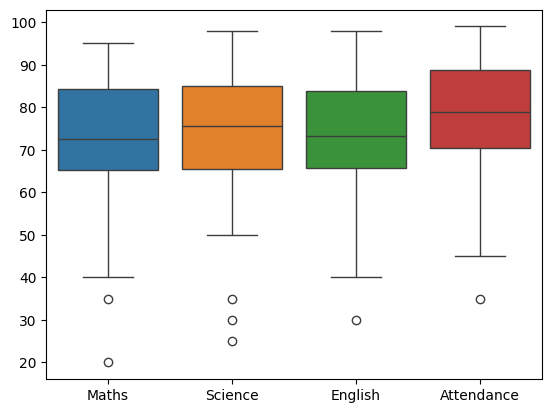

In [18]:
# find out outliers using boxplot
sns.boxplot(data=df[['Maths','Science','English','Attendance']])

In [19]:
# detect outliers using boxplot and use quantile method for Q1=0.25 Q2=0.50 Q3=0.75
cols = ['Maths','Science','English','Attendance']

In [20]:
all_Q1 = df[cols].quantile(0.25)

In [21]:
all_Q1

Maths         65.25
Science       65.50
English       65.75
Attendance    70.50
Name: 0.25, dtype: float64

In [22]:
all_Q2=df[cols].quantile(0.50)

In [23]:
all_Q2

Maths         72.500000
Science       75.500000
English       73.339286
Attendance    79.000000
Name: 0.5, dtype: float64

In [24]:
all_Q3=df[cols].quantile(0.75)


In [25]:
all_Q3


Maths         84.25
Science       85.00
English       83.75
Attendance    88.75
Name: 0.75, dtype: float64

In [26]:
IQR=all_Q3-all_Q1
lower = all_Q1 - 1.5*IQR
print("IQR",IQR)
print("LOW",lower)
upper=all_Q3+1.5*IQR
print("upper",upper)


IQR Maths         19.00
Science       19.50
English       18.00
Attendance    18.25
dtype: float64
LOW Maths         36.750
Science       36.250
English       38.750
Attendance    43.125
dtype: float64
upper Maths         112.750
Science       114.250
English       110.750
Attendance    116.125
dtype: float64


In [28]:
# REPLACE THE OUTLIERS WITH MEDIAN
for col in cols:
    df.loc[(df[col] < lower[col]) , col] = lower[col]
    df.loc[(df[col] > upper[col]) , col] = upper[col]

In [29]:
df

,Student_ID,Maths,Science,English,Attendance
0,1,78.000000,82.000000,75.000000,85.000000
1,2,85.000000,79.000000,80.000000,90.000000
2,3,71.269231,88.000000,70.000000,78.000000
3,4,95.000000,72.222222,85.000000,95.000000
4,5,40.000000,36.250000,72.678571,60.000000
5,6,88.000000,90.000000,88.000000,77.703704
6,7,71.269231,85.000000,65.000000,88.000000
7,8,72.000000,72.222222,78.000000,92.000000
8,9,66.000000,70.000000,68.000000,75.000000
9,10,55.000000,60.000000,58.000000,65.000000


In [30]:
df.median()


Student_ID    15.500000
Maths         72.500000
Science       75.500000
English       73.339286
Attendance    79.000000
dtype: float64

<Axes: >

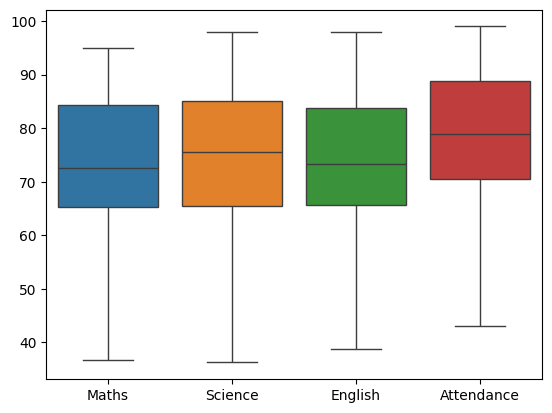

In [31]:
sns.boxplot(data=df[['Maths','Science','English','Attendance']])


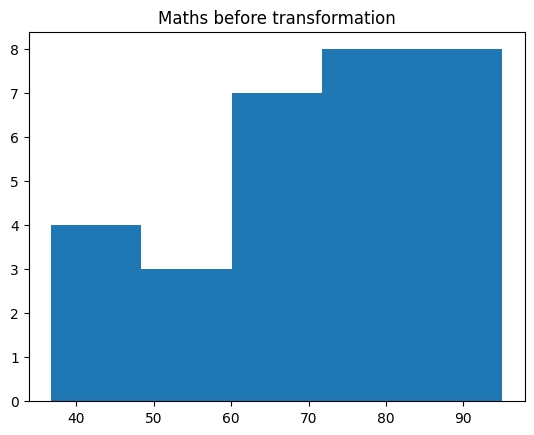

In [32]:
# TRANSFORMATION range -0.5 to 0.5 approximately symmetric(+ve) -1 < -0.5 and 0.5 < 1 moderately symmetric(
# ve

plt.hist(df['Maths'],bins=5)
plt.title("Maths before transformation")
plt.show()


In [33]:
df["Maths"].skew()


np.float64(-0.7157680000711928)

In [34]:
max=df["Maths"].max()
df["Maths_reflected"]=max+1-df["Maths"]
df["Maths_transformed"]=np.sqrt(df["Maths_reflected"])
df["Maths_transformed"].skew()

np.float64(-0.14535539173782094)

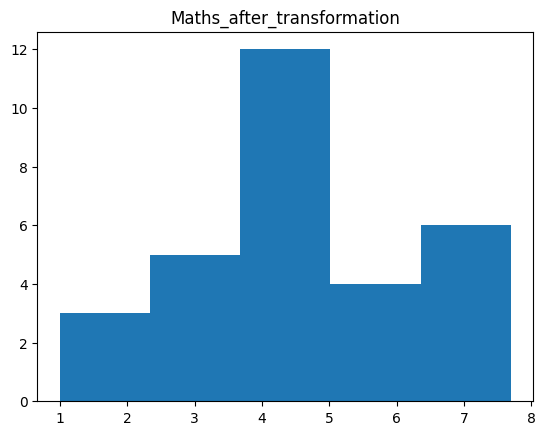

In [35]:
plt.hist(df['Maths_transformed'],bins=5)
plt.title("Maths_after_transformation")
plt.show()